## Supplementary Material:

This notebook is used to predict the vapor - liquid equilibria (VLE) at 94 kPa and liquid mass density at 298.15 K and 101.30 kPa for hexane + cyclopentyl methyl ether + propan-1-ol ternary mixture using the SAFT-VR Mie EoS proposed by Lafitte et al. 

This notebook uses an external Excel file (experimental_data.xlsx) which contains the experimental data and the SGTPy suite, which is free download at https://pypi.python.org/pypi/sgtpy/

For further details, the reader is redirected to “I. Huenuvil-Pacheco, M. Cartes and A. Mejía. Toward Sustainable Fuel Formulations: Thermophysical Assessment of a Synthetic Oxygenated Blend Formed by hexane + cyclopentyl methyl ether + propan-1-ol” by submitted to Sustainable Energy & Fuels (2025).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sgtpy import component, mixture, saftvrmie
from sgtpy.equilibrium import bubbleTy, bubblePy, dewTx, dewPx

In [2]:
# Creating pure components
hexane = component('hexane', ms = 1.96720036, sigma = 4.54762477, eps = 377.60127994, 
                   lambda_r = 18.41193194, lambda_a = 6.0, cii = 3.581510586936205e-19 )

cpme = component('cpme', ms = 2.34183523, sigma = 4.12538522, eps = 344.80694006, lambda_r = 14.1775199,
                 lambda_a = 6.0, sites = [0,0,1], cii = 3.516252062709723e-19)

propanol = component('propanol', ms = 2.2513, sigma = 3.6008 , eps = 253.45,
                    lambda_r = 11.960, lambda_a = 6., eAB = 2794.88, rcAB = 0.3481,sites=[1,0,1], cii= 8.67969723e-20)

# Creating a mixture: hexane (1) + cpme (2) + propanol (3)
mix = hexane + cpme + propanol


# setting up kij and lij interaction parameters  (fitted to experimental VLE)

k12, l12 = np.array([ 0.00295, 0]) # hexane (1) cpme (2)

k13, l13 = np.array([ 4.227e-03, 0]) # hexane (1) propanol (3)

k23, l23 = np.array([ 0.0123,  0]) # cpme (2) propanol (3) with rcAB

r12 = 0
rc13 = 1.312e+00
rc23 = 2.206   #rc induced association


# setting up interaction corrections
Kij = np.array([[0., k12, k13], [k12, 0., k23], [k13, k23, 0.]])
Lij = np.array([[0., l12, l13], [l12, 0., l23], [l13, l23, 0.]])
mix.kij_saft(Kij)
mix.lij_saft(Lij)

eos = saftvrmie(mix) 

eos.eABij[2,0] = propanol.eAB / 2
eos.eABij[0,2] = propanol.eAB / 2
eos.rcij[2,0] = rc13 * 1e-10
eos.rcij[0,2] = rc13 * 1e-10

eos.eABij[2,1] = propanol.eAB / 2
eos.eABij[1,2] = propanol.eAB / 2
eos.rcij[2,1] = rc23 * 1e-10
eos.rcij[1,2] = rc23 * 1e-10



In [3]:
# reading excel file
df = pd.read_excel('experimental_data.xlsx', 'vle')
# reading dataframe data
Texp = np.asarray(df.iloc[:, 0])  # K
Pexp = np.asarray(df.iloc[:, 1], dtype=float)  # Pa
# liquid phase composition
xhexane = np.asarray(df.iloc[:, 2])
xcpme = np.asarray(df.iloc[:, 3])
xpropanol = np.asarray(df.iloc[:, 4])
Xexp = np.array([xhexane, xcpme, xpropanol])
# vapor phase composition
yhexane = np.asarray(df.iloc[:, 5])
ycpme = np.asarray(df.iloc[:, 6])
ypropanol = np.asarray(df.iloc[:, 7])
Yexp = np.array([yhexane, ycpme, ypropanol])

df.head(n=5)

,T/K,P/Pa,x hexane,x CPME,x propanol,y hexane,y CPME,y propanol
0,365.206667,94000,0.075719,0.817843,0.106437,0.227260,0.571022,0.201719
1,362.830000,94000,0.071133,0.732949,0.195917,0.217742,0.487068,0.295190
2,361.005000,94000,0.073289,0.634645,0.292066,0.231093,0.411066,0.357841
3,359.676667,94000,0.068249,0.544920,0.386831,0.250180,0.354156,0.395664
4,358.493333,94000,0.071925,0.440069,0.488005,0.276794,0.295093,0.428113


In [4]:
n = len(Texp)
P = np.zeros(n)
X = np.zeros([3, n])

for i in range(n):
    X[:, i], P[i] = dewPx(Xexp[:, i], Pexp[i], Yexp[:, i], Texp[i], eos)
    
errorP = 100. * np.mean(np.abs(P/Pexp - 1))
errorX1 = 100. * np.mean(np.abs(X[0] - Xexp[0]))
errorX2 = 100. * np.mean(np.abs(X[1] - Xexp[1]))
errorX3 = 100. * np.mean(np.abs(X[2] - Xexp[2]))

print('Error P:', errorP)
print('Error X hexane:', errorX1)
print('Error X cpme:', errorX2)
print('Error X propanol:', errorX3)

Error P: 1.9325806536682695
Error X hexane: 1.0980048308056851
Error X cpme: 2.424583290676808
Error X propanol: 3.1664027779804664


In [5]:
n = len(Texp)

T = np.zeros(n)
X = np.zeros([3, n])

for i in range(n):
    X[:, i], T[i] = dewTx(Xexp[:, i], Texp[i], Yexp[:, i], Pexp[i], eos)
    
errorT = 100. * np.mean(np.abs(T/Texp - 1))
errorX1 = 100. * np.mean(np.abs(X[0] - Xexp[0]))
errorX2 = 100. * np.mean(np.abs(X[1] - Xexp[1]))
errorX3 = 100. * np.mean(np.abs(X[2] - Xexp[2]))

print('Error T:', errorT)
print('Error X hexane:', errorX1)
print('Error X cpme:', errorX2)
print('Error X propanol:', errorX3)

Error T: 0.15193329368185163
Error X hexane: 0.92237048618092
Error X cpme: 2.3763428719941535
Error X propanol: 2.9413156848137603


In [6]:
n = len(Texp)

P = np.zeros(n)
Y = np.zeros([3, n])

for i in range(n):
    Y[:, i], P[i] = bubblePy(Yexp[:, i], Pexp[i], Xexp[:, i], Texp[i], eos)
    
errorP = 100. * np.mean(np.abs(P/Pexp - 1))
errorY1 = 100. * np.mean(np.abs(Y[0] - Yexp[0]))
errorY2 = 100. * np.mean(np.abs(Y[1] - Yexp[1]))
errorY3 = 100. * np.mean(np.abs(Y[2] - Yexp[2]))

print('Error P:', errorP)
print('Error Y hexane:', errorY1)
print('Error Y cpme:', errorY2)
print('Error Y propanol:', errorY3)

Error P: 2.056934430821795
Error Y hexane: 0.710604985590232
Error Y cpme: 1.3376224317738614
Error Y propanol: 1.0160933557572056


In [7]:
n = len(Texp)

T = np.zeros(n)
Y = np.zeros([3, n])

for i in range(n):
    Y[:, i], T[i] = bubbleTy(Yexp[:, i], Texp[i], Xexp[:, i], Pexp[i], eos)
    
errorT = 100. * np.mean(np.abs(T/Texp - 1))
errorY1 = 100. * np.mean(np.abs(Y[0] - Yexp[0]))
errorY2 = 100. * np.mean(np.abs(Y[1] - Yexp[1]))
errorY3 = 100. * np.mean(np.abs(Y[2] - Yexp[2]))

print('Error T:', errorT)
print('Error Y hexane:', errorY1)
print('Error Y cpme:', errorY2)
print('Error Y propanol:', errorY3)

Error T: 0.18157281506399556
Error Y hexane: 0.8186301231912034
Error Y cpme: 1.3337402050524103
Error Y propanol: 0.9864449037907718


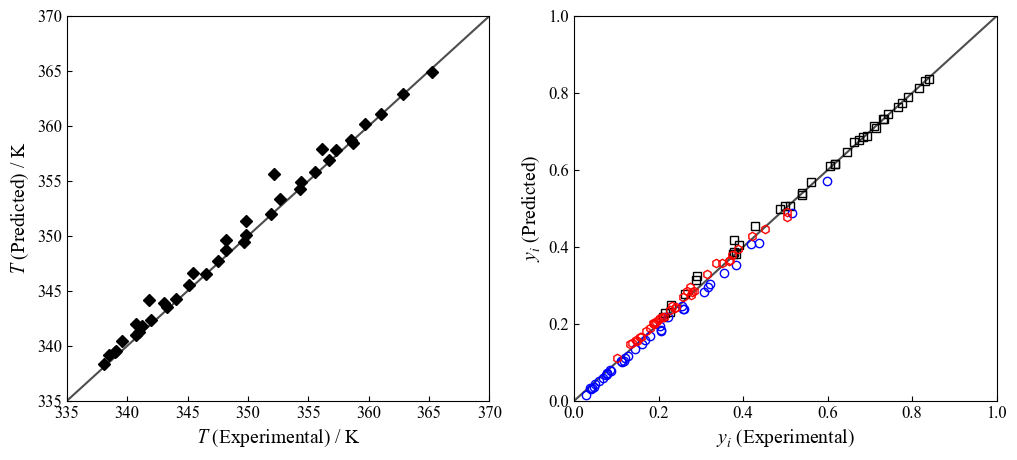

In [8]:
plt.rc('text', usetex=False )

plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fontsize = 14

fig = plt.figure(figsize = (12,5))

# Bubble Temperature parity plot
ax = fig.add_subplot(121)

Tlimits = [335, 370]
ax.plot(Tlimits, Tlimits, c = '0.3')
ax.plot(Texp, T, 'D', color = 'k',markersize = '6')
ax.set_xlim(Tlimits)
ax.set_ylim(Tlimits)
ax.set_ylabel(r'$T$ (Predicted) / K', fontsize=fontsize)
ax.set_xlabel(r'$T$ (Experimental) / K', fontsize=fontsize)
ax.tick_params(direction='in')

# Vapor composition parity plot
ax2 = fig.add_subplot(122)
Ylimits = [0, 1]
ax2.plot(Ylimits, Ylimits, c = '0.3')
ax2.plot(Y[0], Yexp[0], 's', color = 'k',mfc = 'none', label='n-Hexane')
ax2.plot(Y[1], Yexp[1], 'o', color = 'b',mfc = 'none', label='CPME')
ax2.plot(Y[2], Yexp[2], 'h', color = 'r',mfc = 'none', label='Propanol')


ax2.set_xlim(Ylimits)
ax2.set_ylim(Ylimits)
ax2.set_ylabel(r'$y_i$ (Predicted)', fontsize=fontsize)
ax2.set_xlabel(r'$y_i$ (Experimental)', fontsize=fontsize)
ax2.tick_params(direction='in')


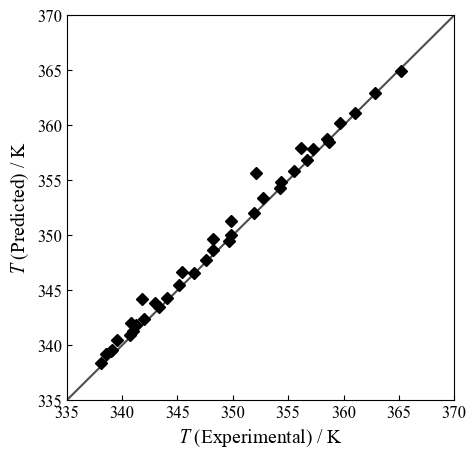

In [9]:
fig = plt.figure(figsize = (5,5))

Tlimits = [335, 370]


plt.plot(Tlimits, Tlimits, c = '0.3')
plt.plot(Texp, T, 'D', color = 'k',markersize = '6')
plt.xlim(Tlimits)
plt.ylim(Tlimits)
plt.ylabel(r'$T$ (Predicted) / K', fontsize=fontsize)
plt.xlabel(r'$T$ (Experimental) / K', fontsize=fontsize)
plt.tick_params(direction='in')

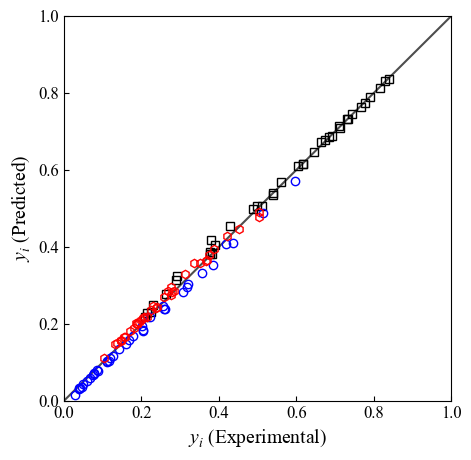

In [10]:
fig = plt.figure(figsize = (5,5))
Ylimits = [0, 1]
plt.plot(Ylimits, Ylimits, c = '0.3')
plt.plot(Y[0], Yexp[0], 's', color = 'k',mfc = 'none', label='n-Hexane')
plt.plot(Y[1], Yexp[1], 'o', color = 'b',mfc = 'none', label='CPME')
plt.plot(Y[2], Yexp[2], 'h', color = 'r',mfc = 'none', label='Propanol')


plt.xlim(Ylimits)
plt.ylim(Ylimits)
plt.ylabel(r'$y_i$ (Predicted)', fontsize=fontsize)
plt.xlabel(r'$y_i$ (Experimental)', fontsize=fontsize)
plt.tick_params(direction='in')


C:\Users\isaia\AppData\Roaming\Python\Python312\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


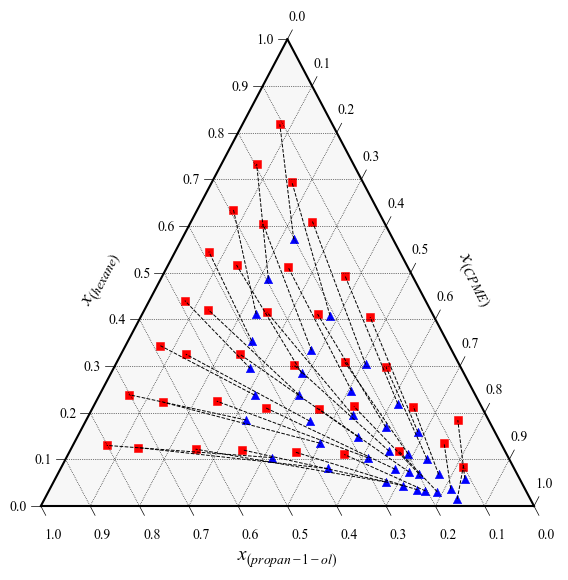

In [11]:
import ternary

figure, tax = ternary.figure(scale=1.0)
figure.set_size_inches(7,7)

tax.boundary()
tax.gridlines(multiple=0.1, color="black",linewidth=0.5)
tax.left_axis_label(r"$x_{(hexane)}$", fontsize=14,offset=0.14)
tax.right_axis_label(r"$x_{(CPME)}$", fontsize=14,offset=0.14)
tax.bottom_axis_label(r"$x_{(propan-1-ol)}$", fontsize=14,offset=0)

tax.get_axes().axis('off')


tax.clear_matplotlib_ticks()



scatter1 = np.transpose(np.array([Yexp[0, :], Yexp[1, :], Yexp[2, :]]))
scatter2 = np.transpose(np.array([Xexp[0, :], Xexp[1, :], Xexp[2, :]]))


tax.scatter(scatter1, marker='^', color='blue', linewidth=0.4)
tax.scatter(scatter2, marker='s', color='red', linewidth=0.4)


c=len(yhexane)

p1=np.zeros([c,3])
p2=np.zeros([c,3])

for k in range(c):
    p1[k]=np.array([yhexane[k],ycpme[k],ypropanol[k]])
    p2[k]=np.array([xhexane[k],xcpme[k],xpropanol[k]])
    tax.line(p1[k],p2[k], linewidth=0.7, color='black', linestyle="--")
    
tax.ticks(axis='lbr', multiple=0.1, linewidth=0.5, tick_formats="%.1f", offset=0.02,fontsize=10,clockwise=True)

tax.show()


## Liquid Densities

In [12]:
# reading excel file
df = pd.read_excel('experimental_data.xlsx', 'density')
# reading dataframe data
Texp = np.asarray(df.iloc[:, 0])  # K
Pexp = np.asarray(df.iloc[:, 1], dtype=float)  # Pa
# liquid phase composition
xhexane = np.asarray(df.iloc[:, 2])
xcpme = np.asarray(df.iloc[:, 3])
xpropanol = np.asarray(df.iloc[:, 4])
Xexp = np.array([xhexane, xcpme, xpropanol])
print(np.shape(Xexp))
# liquid density
rho_exp = np.asarray(df.iloc[:, 5])  #kg/m3


df.head()

(3, 41)


,T / K,P / Pa,xHexane,xCPME,xPropanol,rho_kg/m3,rho_g/cm3
0,298.15,101325,0.090337,0.101900,0.807763,787.713311,0.787713
1,298.15,101325,0.084394,0.205837,0.709769,798.157454,0.798157
2,298.15,101325,0.087503,0.297349,0.615148,805.362463,0.805362
3,298.15,101325,0.082225,0.401875,0.515900,813.793103,0.813793
4,298.15,101325,0.088598,0.522156,0.389246,819.407008,0.819407


In [13]:
n = len(Texp)
rho = np.zeros(n)

#computing liquid density in mol/m3
for i in range(n):
    rho[i] = eos.density(Xexp[:, i], Texp[i], Pexp[i], 'L')

# molar weight array
Mw = np.array([86.18, 100.16, 60.0959]) #g/mol
Mwmix = np.matmul(Mw, Xexp) #g/mol
rho_eos = rho*Mwmix # g/m3
rho_eos /= 1000 # kg/m3

errorrho = 100. * np.mean(np.abs(rho_eos/rho_exp - 1))

print('Error density:', errorrho)

Error density: 0.1286812259306123


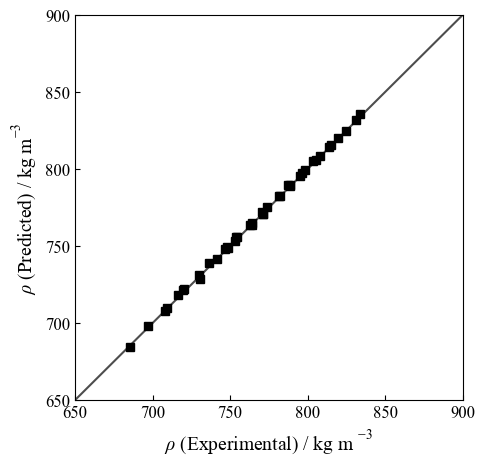

In [14]:

fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111)

ax.plot([600, 900], [600, 900], c = '0.3')
ax.plot(rho_exp, rho_eos, 's', color = 'k')


ax.set_ylabel(r'$\rho$ (Predicted) / kg m$^{-3}$', fontsize=fontsize)
ax.set_xlabel(r'$\rho$ (Experimental) / kg m $^{-3}$', fontsize=fontsize)

lim = [650, 900]
ax.set_xlim(lim)
ax.set_ylim(lim)

ax.tick_params(direction='in')
